In [1]:
# ─── Environment Setup (do not edit) ────────────────────────────────────────
import os, sys
from pathlib import Path

def _detect_platform():
    try:
        import google.colab  # noqa: F401
        return "colab", False
    except ImportError:
        pass
    if Path("/workspace").exists() and os.environ.get("VAST_CONTAINERLABEL"):
        return "vastai", False
    if Path("/workspace").exists():
        return "vastai", True
    if sys.platform == "win32":
        return "windows", False
    if sys.platform == "darwin":
        return "mac", False
    return None, True

PLATFORM, _uncertain = _detect_platform()

if PLATFORM == "colab":
    from google.colab import drive
    drive.mount("/content/drive")

try:
    _nb_path = Path(__file__).resolve()
except NameError:
    _nb_path = Path.cwd()

if PLATFORM == "colab":
    PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis_Final/fake-news-detection")
else:
    PROJECT_ROOT = _nb_path.parents[1]

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

_env_map = {
    "colab":   PROJECT_ROOT / ".env.colab",
    "vastai":  PROJECT_ROOT / ".env.vastai",
    "windows": PROJECT_ROOT / ".env.windows",
    "mac":     PROJECT_ROOT / ".env.mac",
}
_env_file = _env_map.get(PLATFORM, PROJECT_ROOT / ".env")

from dotenv import load_dotenv
if not _env_file.exists():
    _fallback = PROJECT_ROOT / ".env"
    _env_file = _fallback if _fallback.exists() else _env_file

load_dotenv(_env_file, override=True)

from utils.env_utils import get_data_root
DATA_ROOT = get_data_root()

print(f"✅ Platform : {PLATFORM or 'unknown'}")
print(f"✅ DATA_ROOT: {DATA_ROOT}")
print(f"{'✅' if DATA_ROOT.exists() else '❌'} Path exists: {DATA_ROOT.exists()}")
# ─────────────────────────────────────────────────────────────────────────────

✅ Platform : mac
✅ DATA_ROOT: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis
✅ Path exists: True


# Phân tích Dữ liệu (EDA) — ViFactCheck Vietnamese Fake News Detection

Notebook này phân tích chi tiết dữ liệu sau khi crawl từ dataset ViFactCheck,  
bao gồm thống kê tổng quan, phân bố nhãn, nguồn tin, chủ đề và đặc trưng văn bản.

**Nguồn dữ liệu:** `tranthaihoa/vifactcheck` (HuggingFace)  
**Bộ dữ liệu crawled:** JSON files tại `DATA_ROOT/data/json/`  
**Splits:** train / dev / test

In [2]:
import json
import warnings
from pathlib import Path
from collections import Counter
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_dataset

warnings.filterwarnings("ignore")

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

LABEL_MAP = {0: "Supported (Đúng)", 1: "Refuted (Sai)", 2: "Not Enough Info (Chưa đủ thông tin)"}
LABEL_COLORS = {0: "#2ecc71", 1: "#e74c3c", 2: "#f39c12"}
SPLIT_COLORS = {"train": "#3498db", "dev": "#9b59b6", "test": "#e67e22"}

print("✅ Imports ready.")

✅ Imports ready.


## 1. Tải dữ liệu

In [3]:
JSON_DIR = DATA_ROOT / "data" / "json"

records = []
for split, hf_split in [("train", "train"), ("dev", "dev"), ("test", "test")]:
    path = JSON_DIR / f"news_data_vifactcheck_{split}_labeled.json"
    with open(path) as f:
        crawled = json.load(f)

    hf_ds = load_dataset("tranthaihoa/vifactcheck", split=hf_split)
    url_meta = {
        row["Url"]: {
            "label":     row["labels"],
            "topic":     row["Topic"],
            "statement": row["Statement"],
            "author":    row["Author"],
        }
        for row in hf_ds
    }

    for rec in crawled:
        url   = rec["metadata"]["source_url"]
        info  = url_meta.get(url, {})
        feat  = rec["features"]
        records.append({
            "id":              rec["id"],
            "split":           split,
            "label":           info.get("label"),
            "label_name":      LABEL_MAP.get(info.get("label"), "Unknown"),
            "topic":           info.get("topic", ""),
            "statement":       info.get("statement", ""),
            "author":          info.get("author", ""),
            "source_url":      url,
            "domain":          feat.get("domain", ""),
            "title":           feat.get("title", ""),
            "text":            feat.get("text", ""),
            "text_length":     feat.get("text_length", 0),
            "paragraph_count": feat.get("paragraph_count", 0),
            "image_count":     feat.get("image_count", 0),
            "has_images":      feat.get("has_images", False),
            "link_count":      feat.get("link_count", 0),
            "crawl_success":   rec["metadata"].get("success", False),
            "crawl_timestamp": rec["metadata"].get("crawl_timestamp", ""),
        })

df = pd.DataFrame(records)
df["has_text"] = df["text_length"] > 0

print(f"✅ Loaded {len(df):,} records across {df['split'].nunique()} splits")
df.head(3)

✅ Loaded 7,232 records across 3 splits


,id,split,label,label_name,topic,statement,author,source_url,domain,title,text,text_length,paragraph_count,image_count,has_images,link_count,crawl_success,crawl_timestamp,has_text
0,89d215119ab8eca5,train,0,Supported (Đúng),ĐÔ THỊ,Phương án để đảm bảo cung cấp nước sạch an toà...,Báo Pháp Luật HCM,https://plo.vn/9-quan-huyen-o-tphcm-se-bi-cup-...,plo.vn,,,0,0,0,False,81,True,2026-06-07T17:33:54.039716,False
1,c7ce67dc4be841df,train,0,Supported (Đúng),Giáo dục,"Ở thời kỳ đầu mới thành lập, CLB chỉ vỏn vẹn 4...",Người lao động,https://nld.com.vn/giao-duc-khoa-hoc/hanh-trin...,nld.com.vn,,,0,0,0,False,0,True,2026-06-07T17:33:56.084256,False
2,b1233e8ace66c810,train,2,Not Enough Info (Chưa đủ thông tin),PHÁP LUẬT,Người vi phạm phải khắc phục và khôi phục nguy...,Tin Tức,https://baotintuc.vn/an-ninh-trat-tu/bat-tam-g...,baotintuc.vn,,,0,0,2,True,0,True,2026-06-07T17:33:56.674088,False


## 2. Tổng quan dataset

In [4]:
overview = pd.DataFrame({
    "Split":        ["train", "dev", "test", "TOTAL"],
    "Số mẫu":       [
        len(df[df.split == "train"]),
        len(df[df.split == "dev"]),
        len(df[df.split == "test"]),
        len(df),
    ],
    "Có văn bản (%)": [
        f"{df[df.split == 'train']['has_text'].mean()*100:.1f}%",
        f"{df[df.split == 'dev']['has_text'].mean()*100:.1f}%",
        f"{df[df.split == 'test']['has_text'].mean()*100:.1f}%",
        f"{df['has_text'].mean()*100:.1f}%",
    ],
    "Có hình ảnh (%)": [
        f"{df[df.split == 'train']['has_images'].mean()*100:.1f}%",
        f"{df[df.split == 'dev']['has_images'].mean()*100:.1f}%",
        f"{df[df.split == 'test']['has_images'].mean()*100:.1f}%",
        f"{df['has_images'].mean()*100:.1f}%",
    ],
    "Crawl thành công (%)": [
        f"{df[df.split == 'train']['crawl_success'].mean()*100:.1f}%",
        f"{df[df.split == 'dev']['crawl_success'].mean()*100:.1f}%",
        f"{df[df.split == 'test']['crawl_success'].mean()*100:.1f}%",
        f"{df['crawl_success'].mean()*100:.1f}%",
    ],
})
overview.set_index("Split", inplace=True)
display(overview.style.set_caption("Bảng 1: Tổng quan dataset ViFactCheck (sau crawl)"))

,Số mẫu,Có văn bản (%),Có hình ảnh (%),Crawl thành công (%)
Split,,,,
train,5062,44.9%,65.6%,100.0%
dev,723,45.6%,65.4%,100.0%
test,1447,44.5%,67.2%,100.0%
TOTAL,7232,44.9%,65.9%,100.0%


## 3. Dữ liệu mẫu

In [5]:
# Hiển thị 2 mẫu từ mỗi split, mỗi nhãn
sample_cols = ["split", "label_name", "domain", "topic", "title", "text_length", "image_count"]

sample_dfs = []
for split in ["train", "dev", "test"]:
    sub = df[(df.split == split) & df.has_text]
    for label in [0, 1, 2]:
        row = sub[sub.label == label]
        if len(row):
            sample_dfs.append(row.iloc[0][sample_cols])

sample_df = pd.DataFrame(sample_dfs).reset_index(drop=True)
sample_df["title"] = sample_df["title"].str[:60] + "..."

display(
    sample_df.style
    .set_caption("Bảng 2: Dữ liệu mẫu (2 mẫu mỗi nhãn × 3 split)")
    .set_properties(**{"text-align": "left"})
)

,split,label_name,domain,topic,title,text_length,image_count
0,train,Supported (Đúng),baochinhphu.vn,Chính trị,Lan toả những giá trị văn hóa tốt đẹp 'chân - thiện - mỹ' củ...,6983,5
1,train,Refuted (Sai),baochinhphu.vn,Xã hội,Nâng cấp thiết bị giám sát đào tạo lái xe tự động phát hiện ...,4601,1
2,train,Not Enough Info (Chưa đủ thông tin),thanhnien.vn,Giáo dục,Giáo dục Anh ngữ phát triển mạnh mẽ bất chấp khủng hoảng hậu...,6656,5
3,dev,Supported (Đúng),thanhnien.vn,Du lịch,Khách sạn lâu đời nhất cố đô Huế tròn 122 tuổi...,2328,6
4,dev,Refuted (Sai),baochinhphu.vn,Chính trị,"Phát huy giá trị báo, tạp chí của Đảng trong thời đại bùng n...",8166,4
5,dev,Not Enough Info (Chưa đủ thông tin),baochinhphu.vn,Chính trị,"Hệ thống xăng dầu, khí đốt phải vận hành đồng bộ, thông suốt...",8369,5
6,test,Supported (Đúng),tienphong.vn,XÃ HỘI,Công bố quyết định của Ban Thường vụ Tỉnh ủy Bình Dương về c...,715,0
7,test,Refuted (Sai),vnexpress.net,Du lịch,Quán bánh cuốn trong ngõ nhỏ 'rẻ nhất Hà Nội'...,4245,2
8,test,Not Enough Info (Chưa đủ thông tin),baochinhphu.vn,Xã hội,Vụ bé trai nghi bị ép hút ma tuý: Cần xử lý nghiêm minh...,4285,1


## 4. Phân bố theo split (train / dev / test)

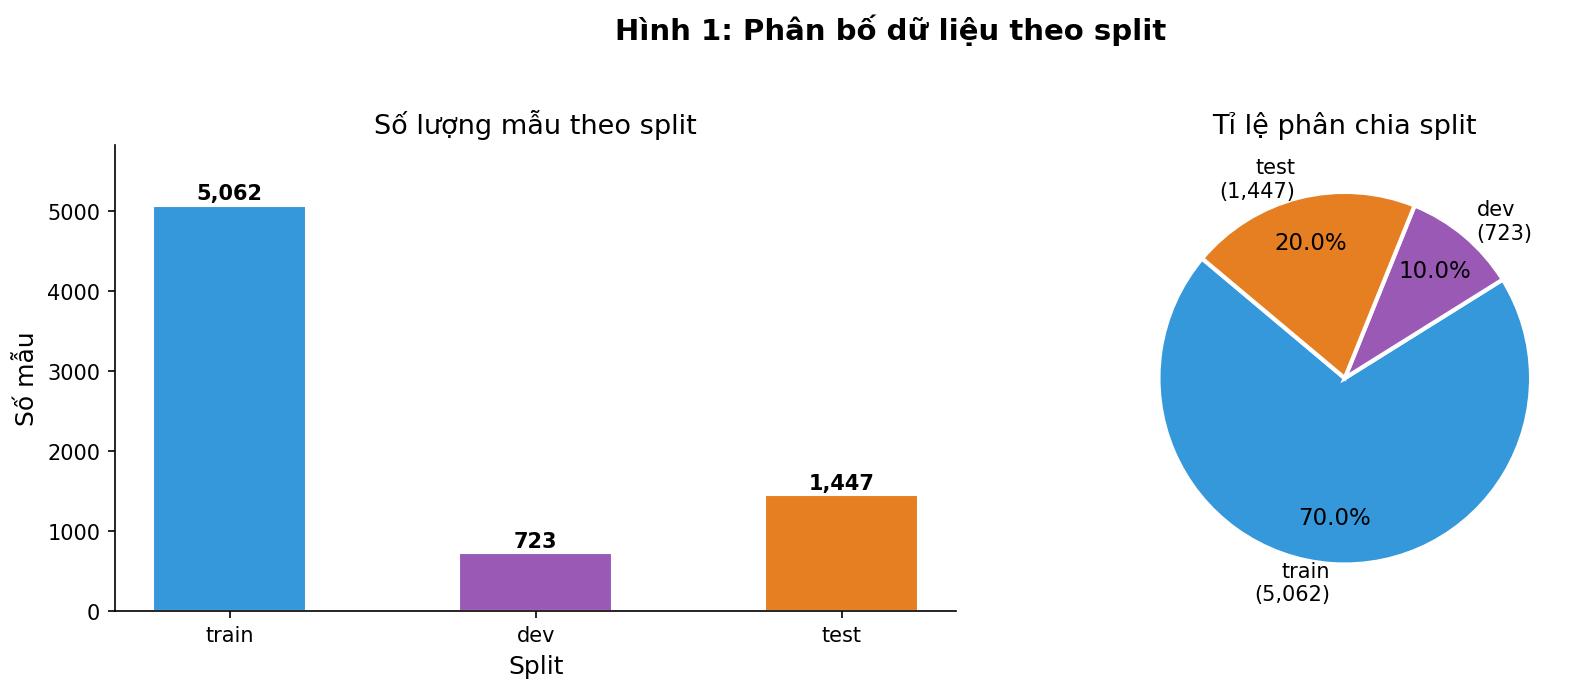

Saved: fig1_split_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Bar chart: count per split
split_counts = df["split"].value_counts().reindex(["train", "dev", "test"])
colors = [SPLIT_COLORS[s] for s in split_counts.index]
bars = axes[0].bar(split_counts.index, split_counts.values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, split_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_title("Số lượng mẫu theo split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Số mẫu")
axes[0].set_ylim(0, split_counts.max() * 1.15)

# Pie chart
axes[1].pie(split_counts.values, labels=[f"{s}\n({v:,})" for s, v in zip(split_counts.index, split_counts.values)],
            colors=colors, autopct="%1.1f%%", startangle=140, pctdistance=0.75,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Tỉ lệ phân chia split")

plt.suptitle("Hình 1: Phân bố dữ liệu theo split", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig1_split_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig1_split_distribution.png")

## 5. Phân bố nhãn (Label Distribution)

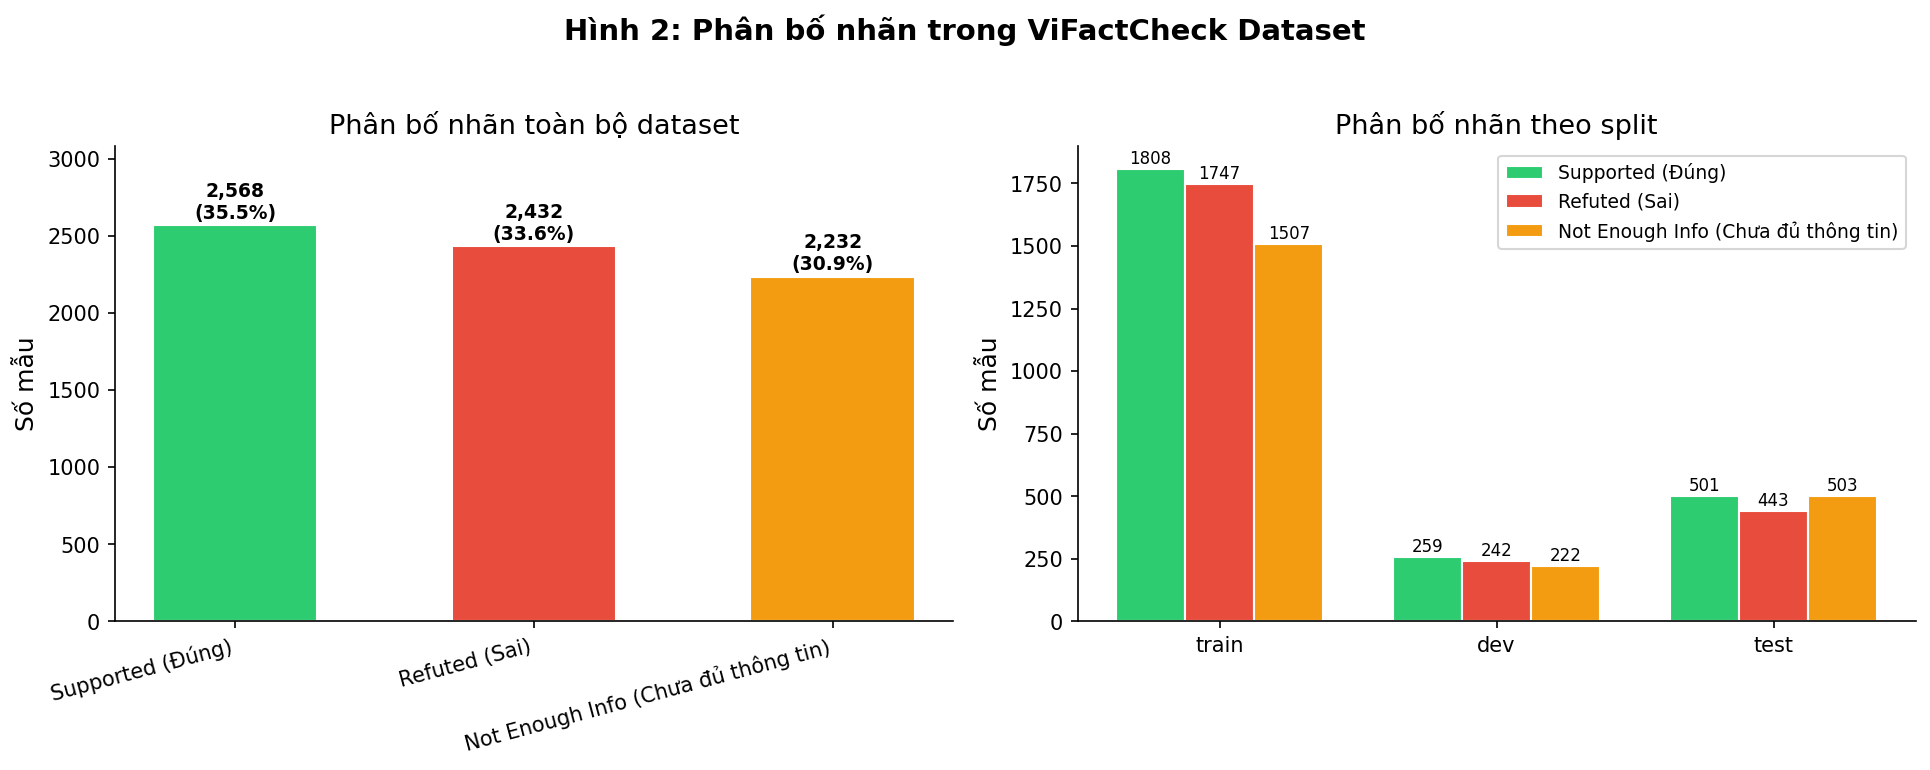

Saved: fig2_label_distribution.png

Ghi chú nhãn:
  0 = Supported   — tuyên bố được xác nhận là đúng bởi bằng chứng
  1 = Refuted     — tuyên bố bị phản bác bởi bằng chứng
  2 = Not Enough Info — không đủ bằng chứng để xác minh


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall label distribution
label_counts = df["label"].value_counts().sort_index()
label_names  = [LABEL_MAP[l] for l in label_counts.index]
colors       = [LABEL_COLORS[l] for l in label_counts.index]

bars = axes[0].bar(label_names, label_counts.values, color=colors, edgecolor="white", width=0.55)
for bar, val in zip(bars, label_counts.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Phân bố nhãn toàn bộ dataset")
axes[0].set_ylabel("Số mẫu")
axes[0].set_ylim(0, label_counts.max() * 1.2)
axes[0].set_xticklabels(label_names, rotation=15, ha="right")

# Per-split label distribution (grouped bar)
split_label = df.groupby(["split", "label"]).size().unstack(fill_value=0)
split_label = split_label.reindex(["train", "dev", "test"])
x = np.arange(len(split_label))
width = 0.25
for i, (label_id, label_name) in enumerate(LABEL_MAP.items()):
    vals = split_label[label_id].values if label_id in split_label.columns else [0]*3
    offset = (i - 1) * width
    bars2 = axes[1].bar(x + offset, vals, width, label=label_name,
                        color=LABEL_COLORS[label_id], edgecolor="white")
    for bar, val in zip(bars2, vals):
        if val > 0:
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                         str(val), ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["train", "dev", "test"])
axes[1].set_title("Phân bố nhãn theo split")
axes[1].set_ylabel("Số mẫu")
axes[1].legend(loc="upper right", fontsize=9)

plt.suptitle("Hình 2: Phân bố nhãn trong ViFactCheck Dataset", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig2_label_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig2_label_distribution.png")
print()
print("Ghi chú nhãn:")
print("  0 = Supported   — tuyên bố được xác nhận là đúng bởi bằng chứng")
print("  1 = Refuted     — tuyên bố bị phản bác bởi bằng chứng")
print("  2 = Not Enough Info — không đủ bằng chứng để xác minh")

## 6. Phân bố theo nguồn tin (Domain)

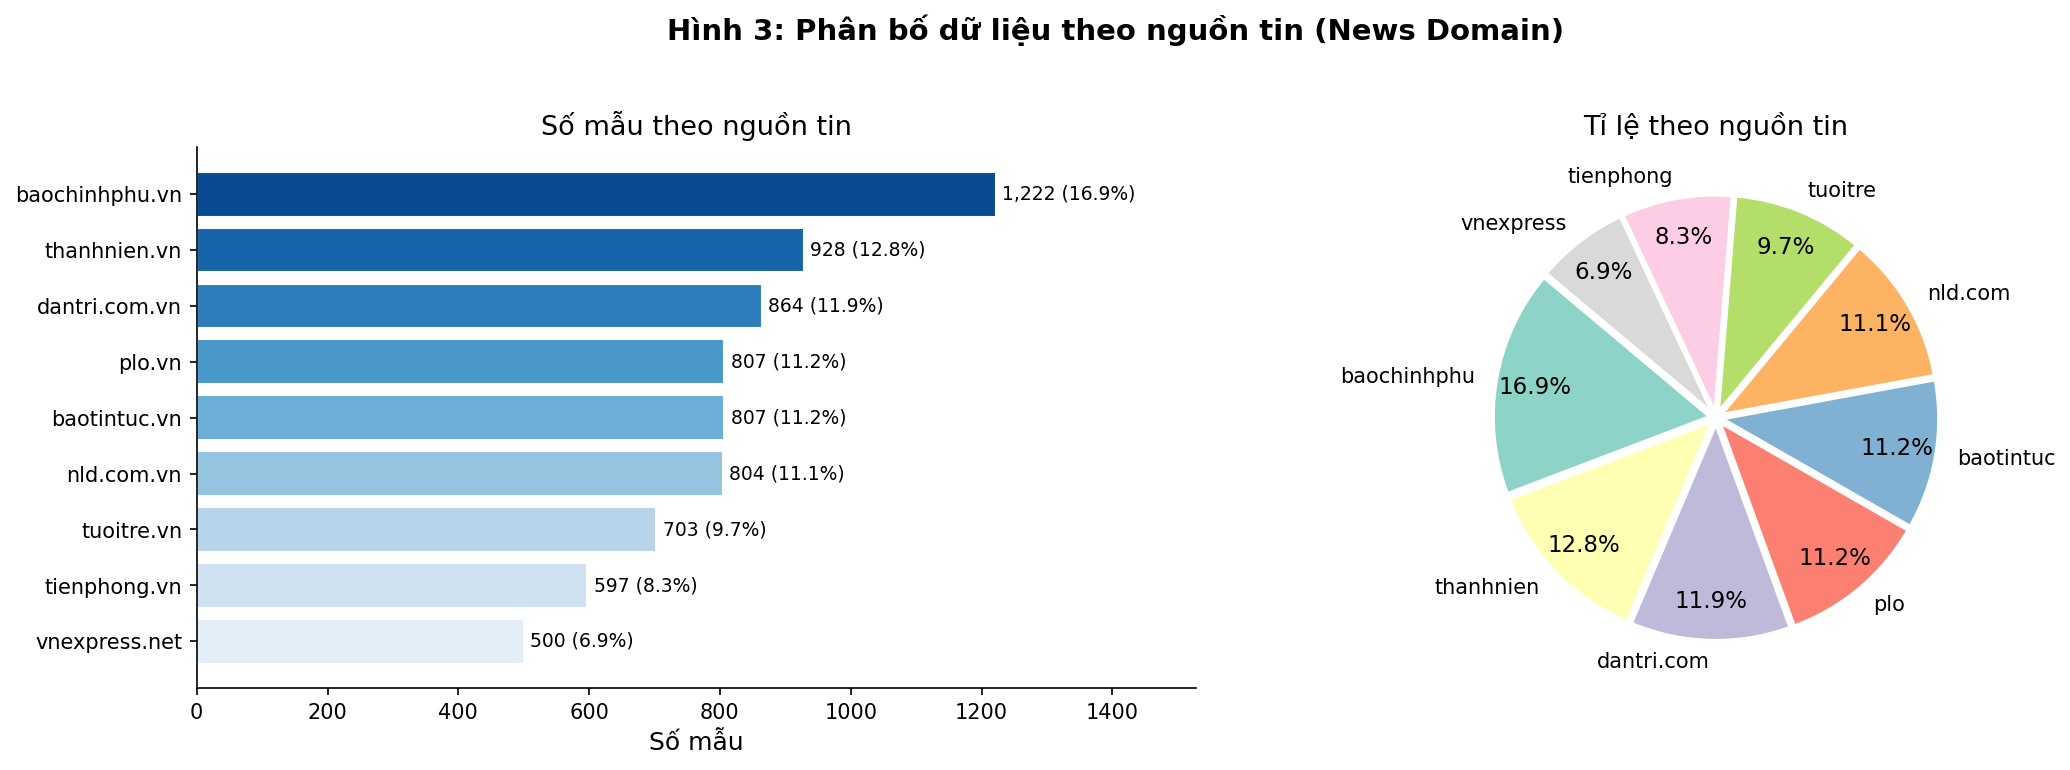

Saved: fig3_domain_distribution.png


In [8]:
domain_counts = df["domain"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Horizontal bar chart
palette = sns.color_palette("Blues_r", len(domain_counts))
axes[0].barh(domain_counts.index[::-1], domain_counts.values[::-1], color=palette[::-1], edgecolor="white")
for i, (idx, val) in enumerate(zip(domain_counts.index[::-1], domain_counts.values[::-1])):
    pct = val / len(df) * 100
    axes[0].text(val + 10, i, f"{val:,} ({pct:.1f}%)", va="center", fontsize=9)
axes[0].set_title("Số mẫu theo nguồn tin")
axes[0].set_xlabel("Số mẫu")
axes[0].set_xlim(0, domain_counts.max() * 1.25)

# Pie chart
explode = [0.03] * len(domain_counts)
axes[1].pie(domain_counts.values,
            labels=[d.replace(".vn","").replace(".net","") for d in domain_counts.index],
            autopct="%1.1f%%", startangle=140, pctdistance=0.82,
            wedgeprops=dict(edgecolor="white", linewidth=1.5),
            colors=sns.color_palette("Set3", len(domain_counts)),
            explode=explode)
axes[1].set_title("Tỉ lệ theo nguồn tin")

plt.suptitle("Hình 3: Phân bố dữ liệu theo nguồn tin (News Domain)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig3_domain_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig3_domain_distribution.png")

## 7. Phân bố theo chủ đề (Topic)

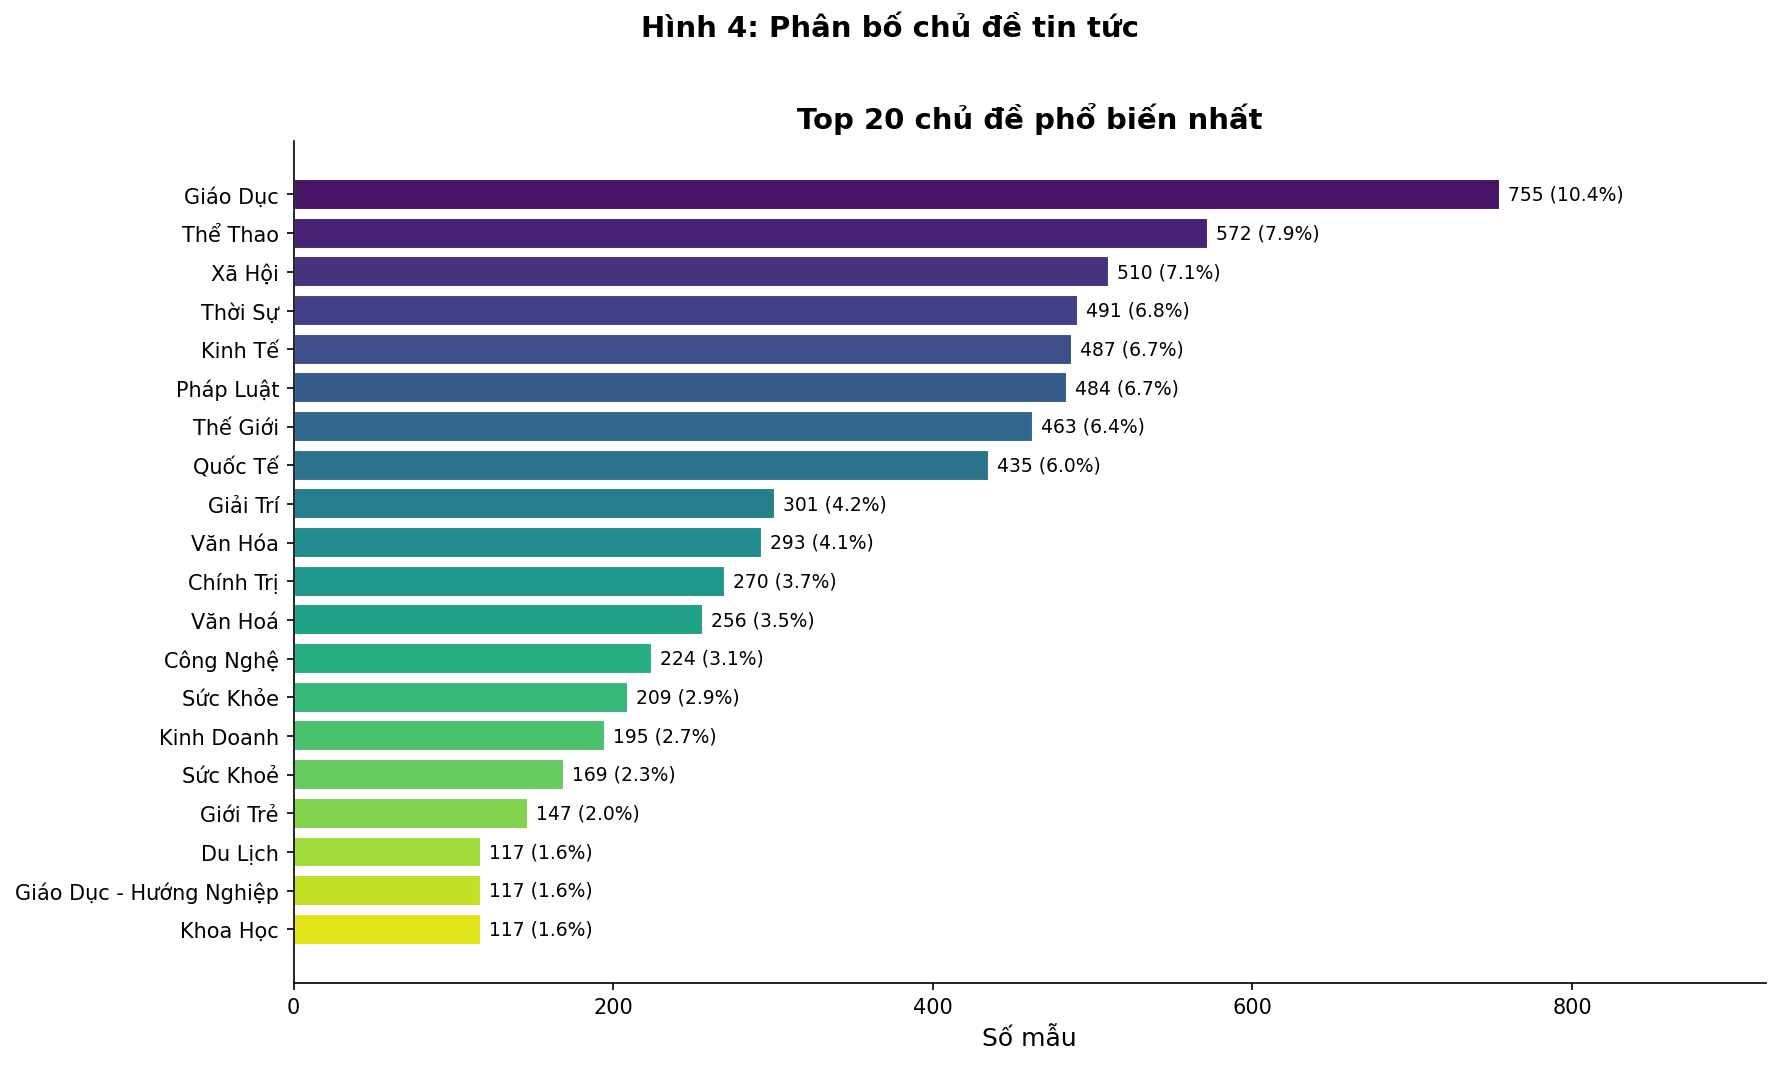

Saved: fig4_topic_distribution.png


In [9]:
# Normalize topic names (uppercase -> title case)
df["topic_norm"] = df["topic"].str.strip().str.title()
topic_counts = df["topic_norm"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette("viridis", len(topic_counts))
bars = ax.barh(topic_counts.index[::-1], topic_counts.values[::-1],
               color=palette[::-1], edgecolor="white")
for bar, val in zip(bars, topic_counts.values[::-1]):
    pct = val / len(df) * 100
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f"{val:,} ({pct:.1f}%)", va="center", fontsize=9)
ax.set_title("Top 20 chủ đề phổ biến nhất", fontsize=14, fontweight="bold")
ax.set_xlabel("Số mẫu")
ax.set_xlim(0, topic_counts.max() * 1.22)

plt.suptitle("Hình 4: Phân bố chủ đề tin tức", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig4_topic_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig4_topic_distribution.png")

## 8. Thống kê văn bản (Text Statistics)

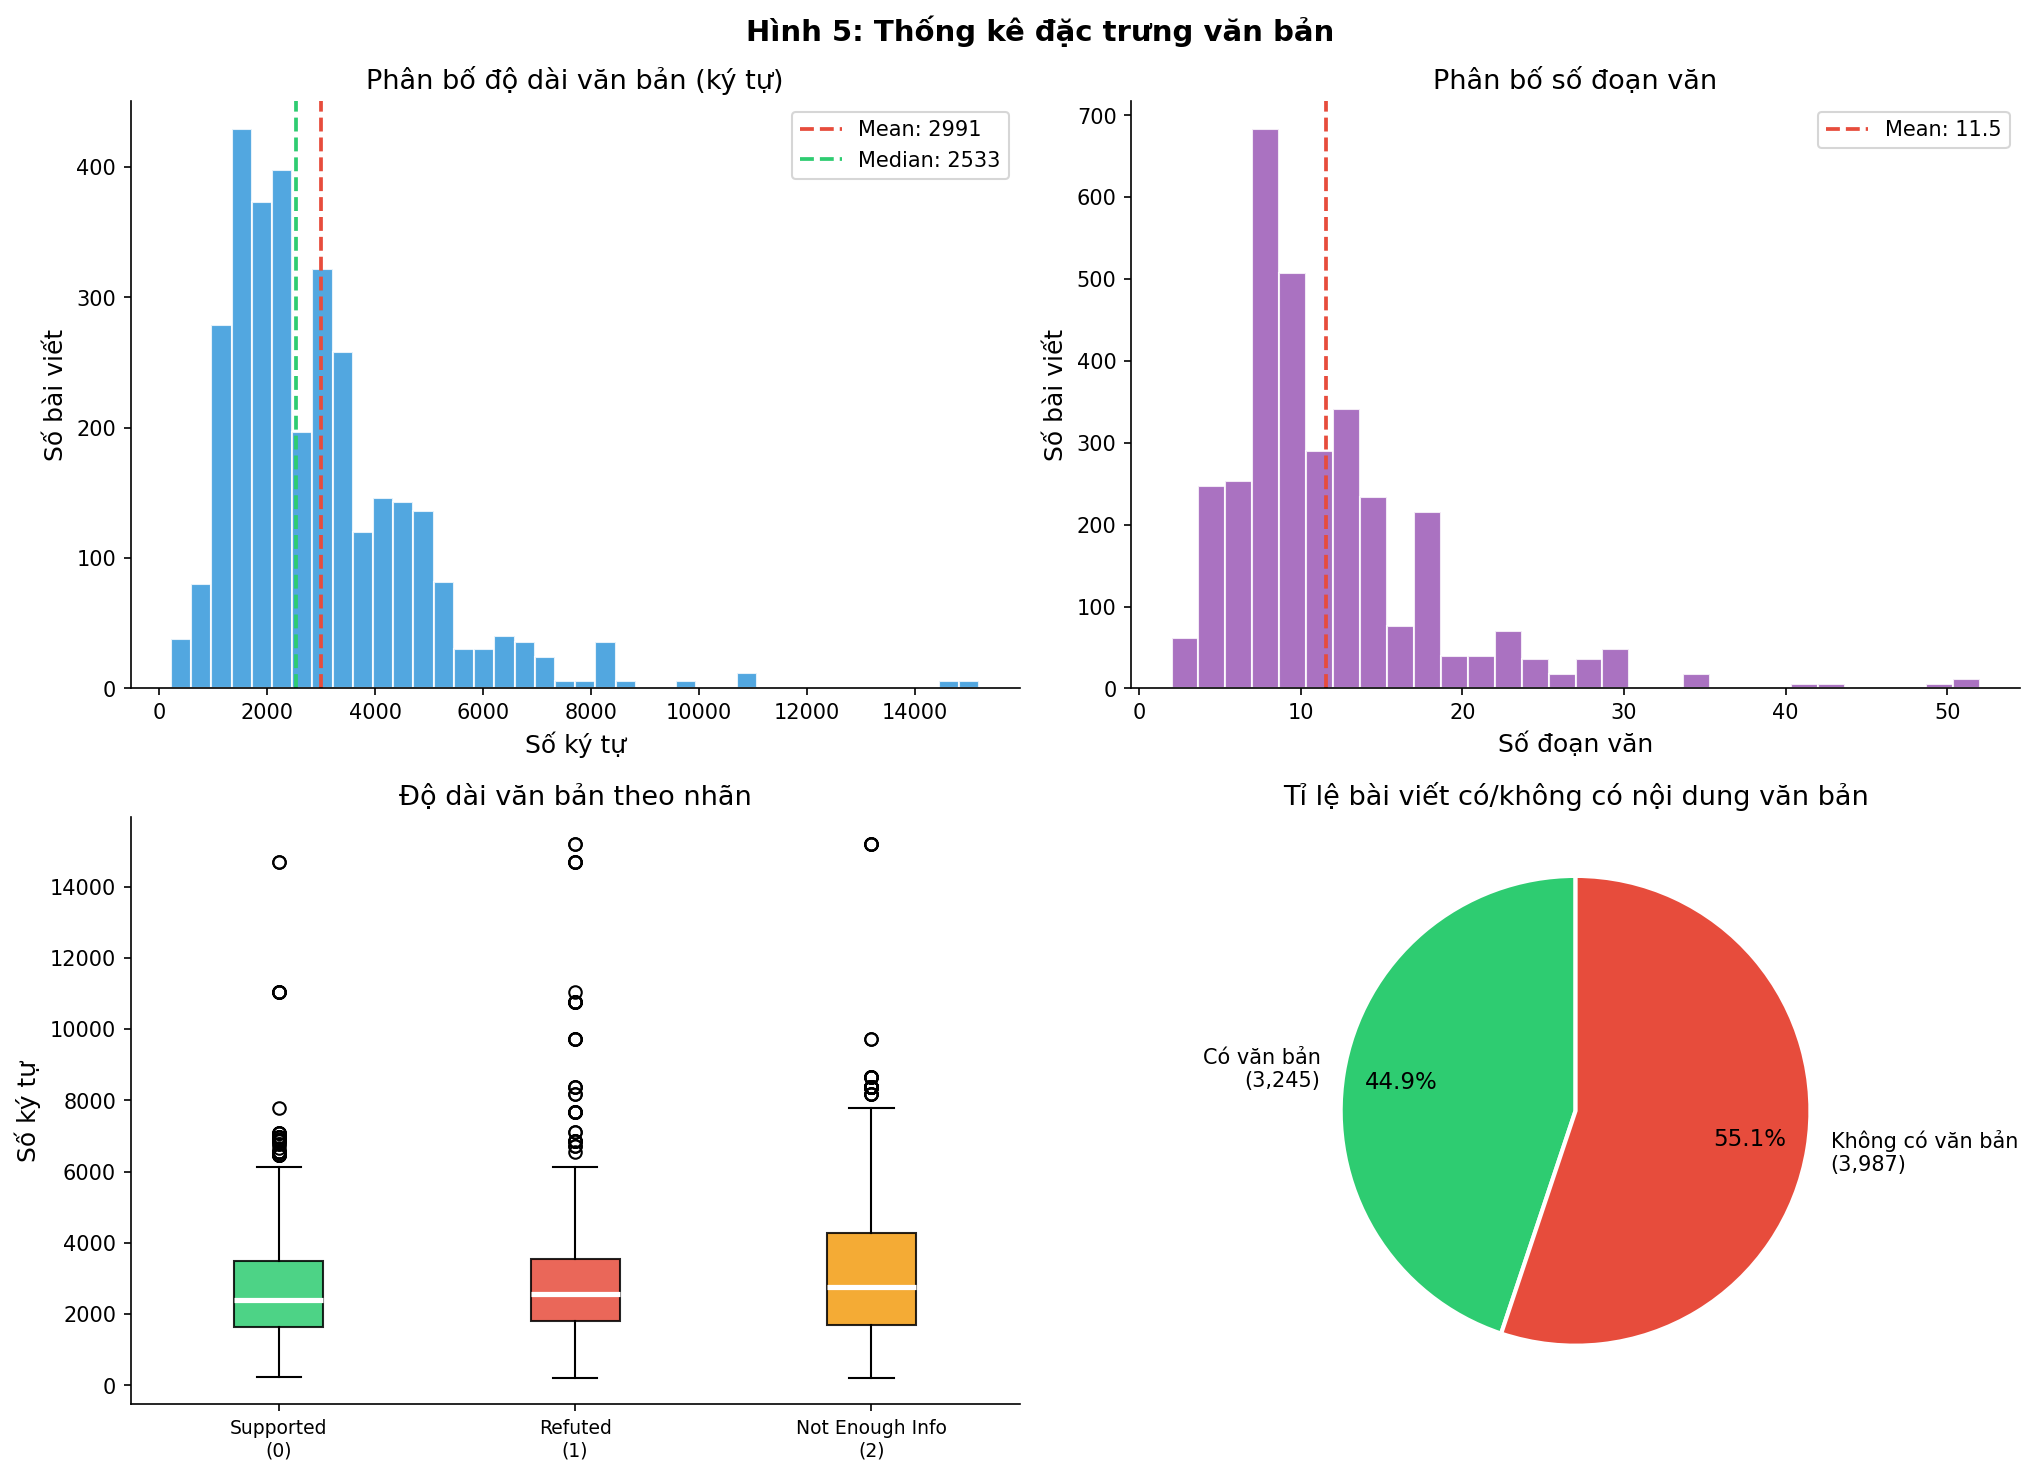

Saved: fig5_text_statistics.png

Thống kê độ dài văn bản (bài viết có nội dung):
count     3245.0
mean      2991.0
std       1827.2
min        215.0
25%       1698.0
50%       2533.0
75%       3798.0
max      15197.0


In [10]:
df_text = df[df["has_text"]].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 8a: Text length histogram
axes[0,0].hist(df_text["text_length"], bins=40, color="#3498db", edgecolor="white", alpha=0.85)
axes[0,0].axvline(df_text["text_length"].mean(), color="#e74c3c", ls="--", lw=1.8, label=f"Mean: {df_text['text_length'].mean():.0f}")
axes[0,0].axvline(df_text["text_length"].median(), color="#2ecc71", ls="--", lw=1.8, label=f"Median: {df_text['text_length'].median():.0f}")
axes[0,0].set_title("Phân bố độ dài văn bản (ký tự)")
axes[0,0].set_xlabel("Số ký tự")
axes[0,0].set_ylabel("Số bài viết")
axes[0,0].legend()

# 8b: Paragraph count histogram
axes[0,1].hist(df_text["paragraph_count"], bins=30, color="#9b59b6", edgecolor="white", alpha=0.85)
axes[0,1].axvline(df_text["paragraph_count"].mean(), color="#e74c3c", ls="--", lw=1.8,
                  label=f"Mean: {df_text['paragraph_count'].mean():.1f}")
axes[0,1].set_title("Phân bố số đoạn văn")
axes[0,1].set_xlabel("Số đoạn văn")
axes[0,1].set_ylabel("Số bài viết")
axes[0,1].legend()

# 8c: Text length by label (boxplot)
label_order = [0, 1, 2]
data_by_label = [df_text[df_text["label"] == l]["text_length"].values for l in label_order]
bp = axes[1,0].boxplot(data_by_label, patch_artist=True, notch=False,
                        medianprops=dict(color="white", linewidth=2.5))
for patch, label in zip(bp["boxes"], label_order):
    patch.set_facecolor(LABEL_COLORS[label])
    patch.set_alpha(0.85)
axes[1,0].set_xticks([1, 2, 3])
axes[1,0].set_xticklabels(["Supported\n(0)", "Refuted\n(1)", "Not Enough Info\n(2)"], fontsize=9)
axes[1,0].set_title("Độ dài văn bản theo nhãn")
axes[1,0].set_ylabel("Số ký tự")

# 8d: Text completeness pie
has_text_count  = df["has_text"].sum()
no_text_count   = (~df["has_text"]).sum()
axes[1,1].pie(
    [has_text_count, no_text_count],
    labels=[f"Có văn bản\n({has_text_count:,})", f"Không có văn bản\n({no_text_count:,})"],
    colors=["#2ecc71", "#e74c3c"], autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2), pctdistance=0.75
)
axes[1,1].set_title("Tỉ lệ bài viết có/không có nội dung văn bản")

plt.suptitle("Hình 5: Thống kê đặc trưng văn bản", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_text_statistics.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig5_text_statistics.png")
print()
print("Thống kê độ dài văn bản (bài viết có nội dung):")
print(df_text["text_length"].describe().round(1).to_string())

## 9. Tỉ lệ hình ảnh (Image Ratio)

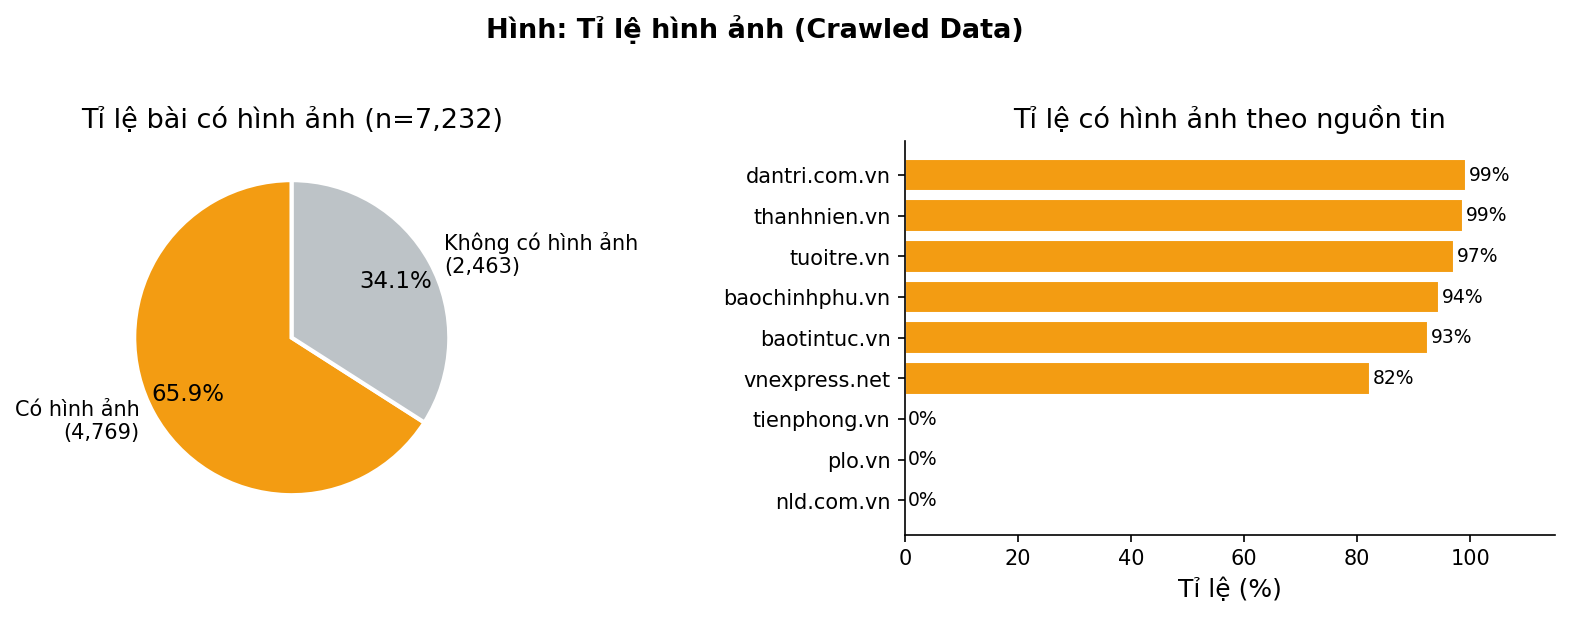

Tổng có ảnh: 4,769 / 7,232 = 65.9%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie: overall
has_i = df["has_images"].sum()
no_i  = (~df["has_images"]).sum()
axes[0].pie(
    [has_i, no_i],
    labels=[f"Có hình ảnh\n({has_i:,})", f"Không có hình ảnh\n({no_i:,})"],
    colors=["#f39c12", "#bdc3c7"], autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2), pctdistance=0.75,
)
axes[0].set_title(f"Tỉ lệ bài có hình ảnh (n={len(df):,})")

# Bar: per domain
img_pct = df.groupby("domain")["has_images"].mean().mul(100).sort_values(ascending=True)
colors_bar = ["#e74c3c" if v < 50 else "#f39c12" for v in img_pct.values]
axes[1].barh(img_pct.index, img_pct.values, color=colors_bar, edgecolor="white")
for i, v in enumerate(img_pct.values):
    axes[1].text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=9)
axes[1].set_title("Tỉ lệ có hình ảnh theo nguồn tin")
axes[1].set_xlabel("Tỉ lệ (%)")
axes[1].set_xlim(0, 115)

plt.suptitle("Hình: Tỉ lệ hình ảnh (Crawled Data)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_image_ratio.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Tổng có ảnh: {has_i:,} / {len(df):,} = {has_i/len(df)*100:.1f}%")

## 9. Nhãn theo nguồn tin (Domain × Label)

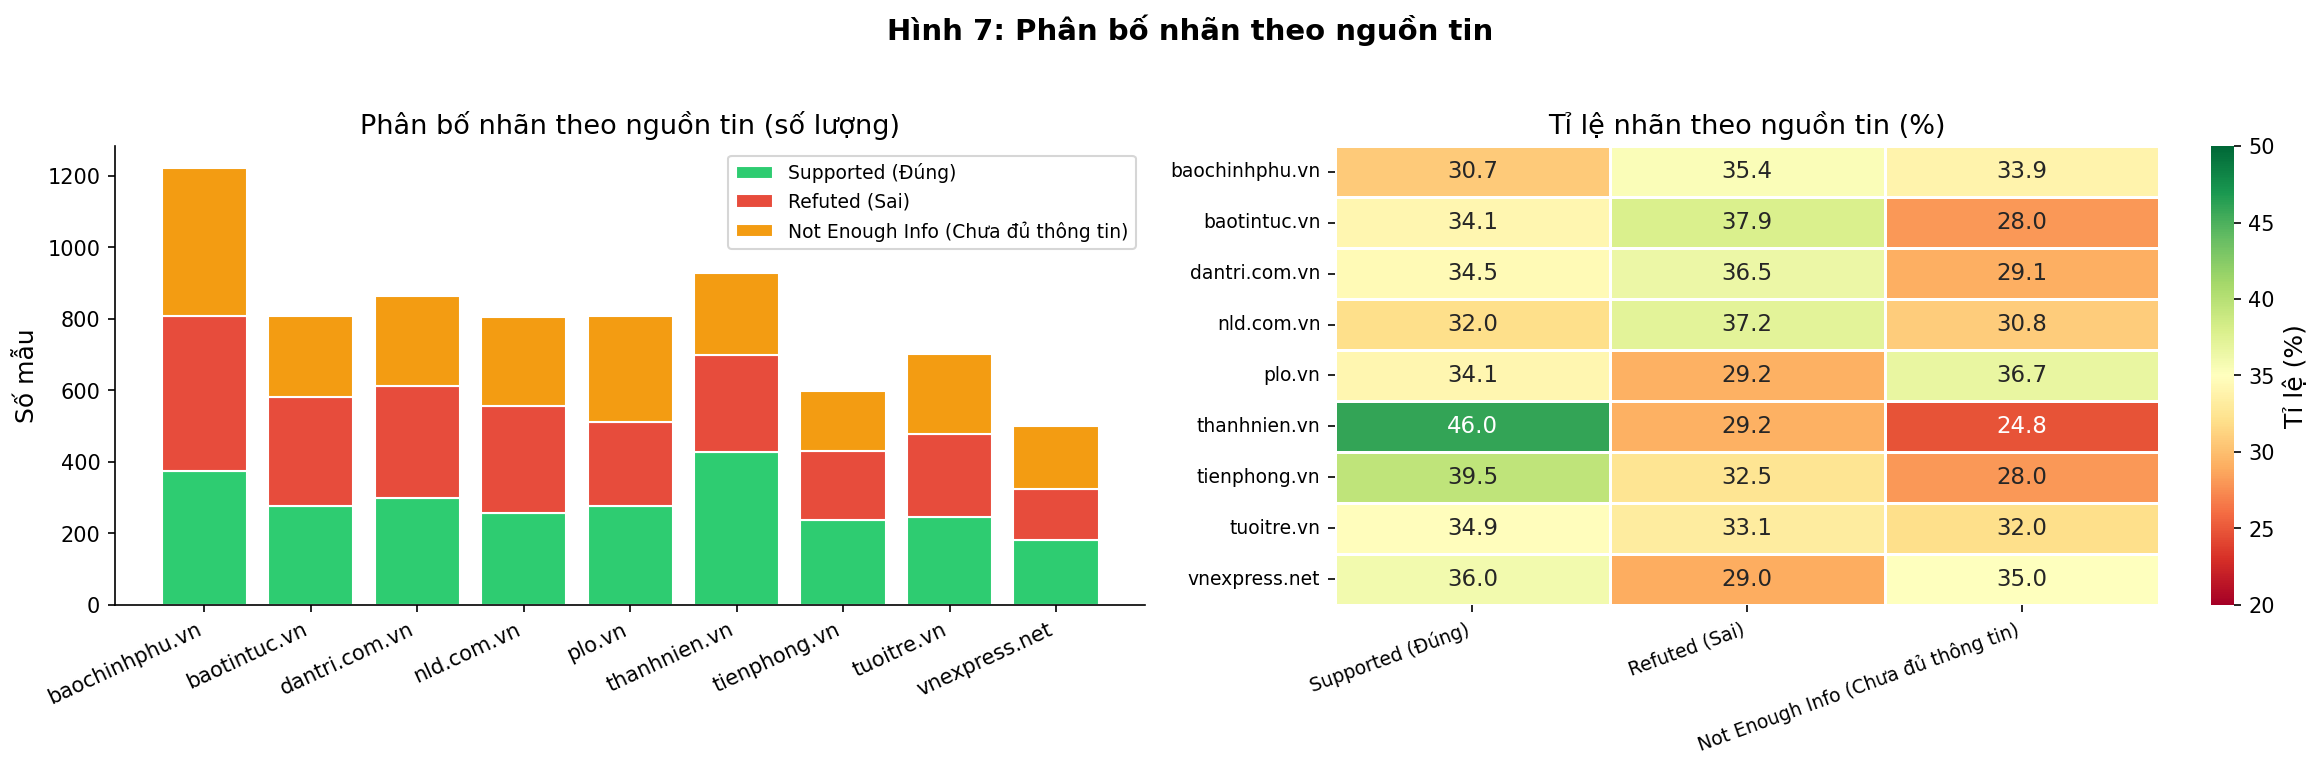

Saved: fig7_domain_label_heatmap.png


In [12]:
domain_label = df.groupby(["domain", "label"]).size().unstack(fill_value=0)
domain_label.columns = [LABEL_MAP[c] for c in domain_label.columns]
domain_label_pct = domain_label.div(domain_label.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar (counts)
bottom = np.zeros(len(domain_label))
for i, col in enumerate(domain_label.columns):
    label_id = [k for k, v in LABEL_MAP.items() if v == col][0]
    bars = axes[0].bar(domain_label.index, domain_label[col].values,
                       bottom=bottom, label=col, color=LABEL_COLORS[label_id], edgecolor="white")
    bottom += domain_label[col].values
axes[0].set_title("Phân bố nhãn theo nguồn tin (số lượng)")
axes[0].set_ylabel("Số mẫu")
axes[0].set_xticklabels(domain_label.index, rotation=25, ha="right")
axes[0].legend(loc="upper right", fontsize=9)

# Heatmap (percentage)
sns.heatmap(domain_label_pct, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.5, ax=axes[1], vmin=20, vmax=50,
            cbar_kws={"label": "Tỉ lệ (%)"})
axes[1].set_title("Tỉ lệ nhãn theo nguồn tin (%)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right", fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle("Hình 7: Phân bố nhãn theo nguồn tin", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig7_domain_label_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig7_domain_label_heatmap.png")

## 10. Bảng thống kê tổng hợp

In [13]:
# Per-split detailed stats
rows = []
for split in ["train", "dev", "test"]:
    sub = df[df.split == split]
    sub_text = sub[sub.has_text]
    rows.append({
        "Split": split,
        "Tổng mẫu": len(sub),
        "Có văn bản": f"{sub.has_text.sum():,} ({sub.has_text.mean()*100:.1f}%)",
        "Có hình ảnh": f"{sub.has_images.sum():,} ({sub.has_images.mean()*100:.1f}%)",
        "Độ dài TB (ký tự)": f"{sub_text.text_length.mean():.0f}" if len(sub_text) else "N/A",
        "Đoạn văn TB": f"{sub_text.paragraph_count.mean():.1f}" if len(sub_text) else "N/A",
        "Supported (0)": f"{(sub.label == 0).sum():,}",
        "Refuted (1)": f"{(sub.label == 1).sum():,}",
        "NEI (2)": f"{(sub.label == 2).sum():,}",
        "Số nguồn tin": sub.domain.nunique(),
        "Số chủ đề": sub.topic_norm.nunique(),
    })

summary_df = pd.DataFrame(rows).set_index("Split")
display(
    summary_df.style
    .set_caption("Bảng 3: Thống kê chi tiết theo split")
    .set_properties(**{"text-align": "right"})
)

,Tổng mẫu,Có văn bản,Có hình ảnh,Độ dài TB (ký tự),Đoạn văn TB,Supported (0),Refuted (1),NEI (2),Số nguồn tin,Số chủ đề
Split,,,,,,,,,,
train,5062,"2,271 (44.9%)","3,323 (65.6%)",2972,11.5,"1,808","1,747","1,507",9,36
dev,723,330 (45.6%),473 (65.4%),2917,11.2,259,242,222,9,32
test,1447,644 (44.5%),973 (67.2%),3095,11.9,501,443,503,9,36


## 11. Thời gian crawl dữ liệu

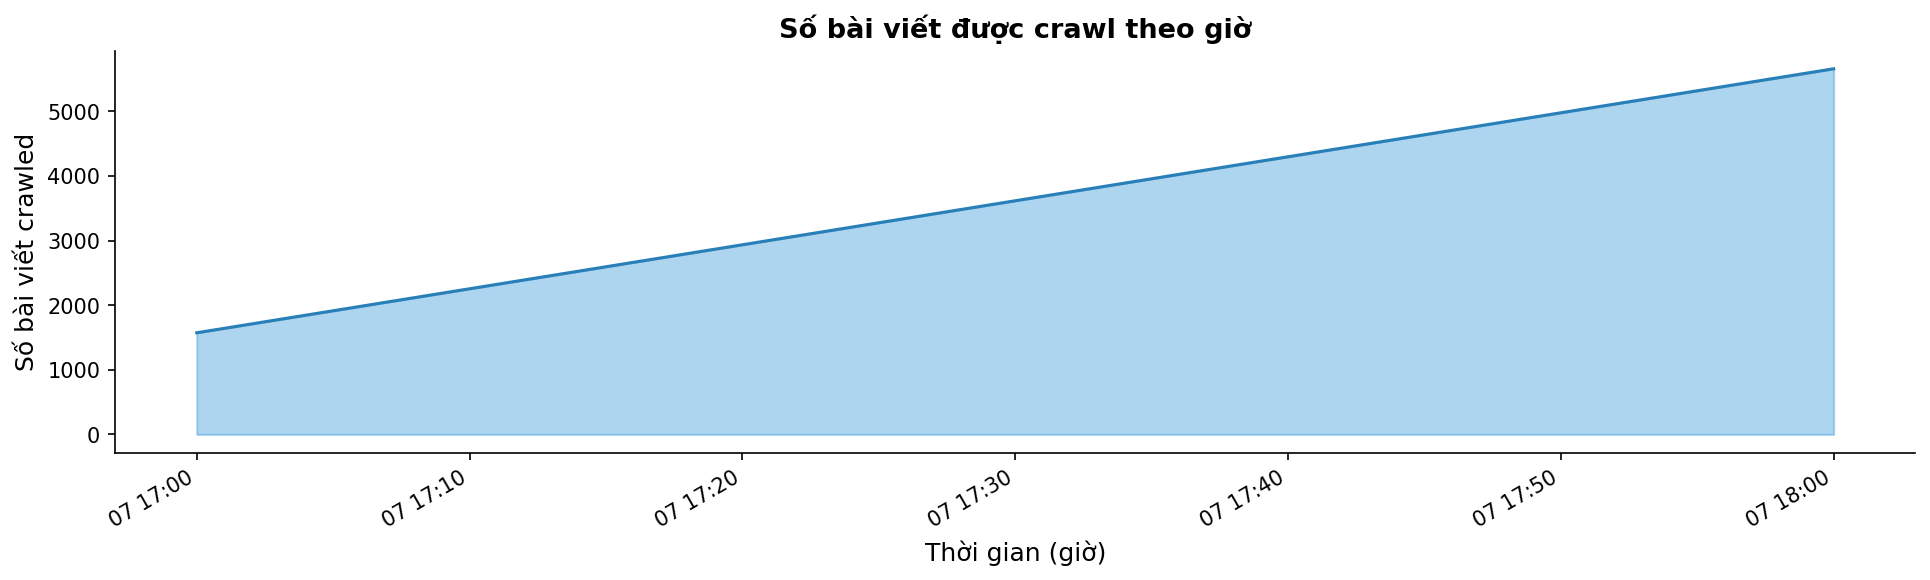

Saved: fig8_crawl_timeline.png
Thời gian bắt đầu crawl: 2026-06-07 17:33:54.039716
Thời gian kết thúc crawl: 2026-06-07 18:55:07.545500


In [14]:
df["crawl_dt"] = pd.to_datetime(df["crawl_timestamp"], errors="coerce")
df["crawl_hour"] = df["crawl_dt"].dt.floor("h")

timeline = df.groupby("crawl_hour").size().reset_index(name="count")
timeline = timeline.dropna(subset=["crawl_hour"])

if len(timeline) > 1:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.fill_between(timeline["crawl_hour"], timeline["count"], alpha=0.4, color="#3498db")
    ax.plot(timeline["crawl_hour"], timeline["count"], color="#2980b9", linewidth=1.5)
    ax.set_title("Số bài viết được crawl theo giờ", fontsize=13, fontweight="bold")
    ax.set_xlabel("Thời gian (giờ)")
    ax.set_ylabel("Số bài viết crawled")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("fig8_crawl_timeline.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Saved: fig8_crawl_timeline.png")
    print(f"Thời gian bắt đầu crawl: {df['crawl_dt'].min()}")
    print(f"Thời gian kết thúc crawl: {df['crawl_dt'].max()}")
else:
    print("Không đủ dữ liệu để vẽ timeline.")

## 12. Chất lượng thu thập theo nguồn tin (Crawled Data Quality)

Phân tích **thực tế dữ liệu đã crawl** từng nguồn tin: domain nào extract được văn bản, tiêu đề, hình ảnh thành công.

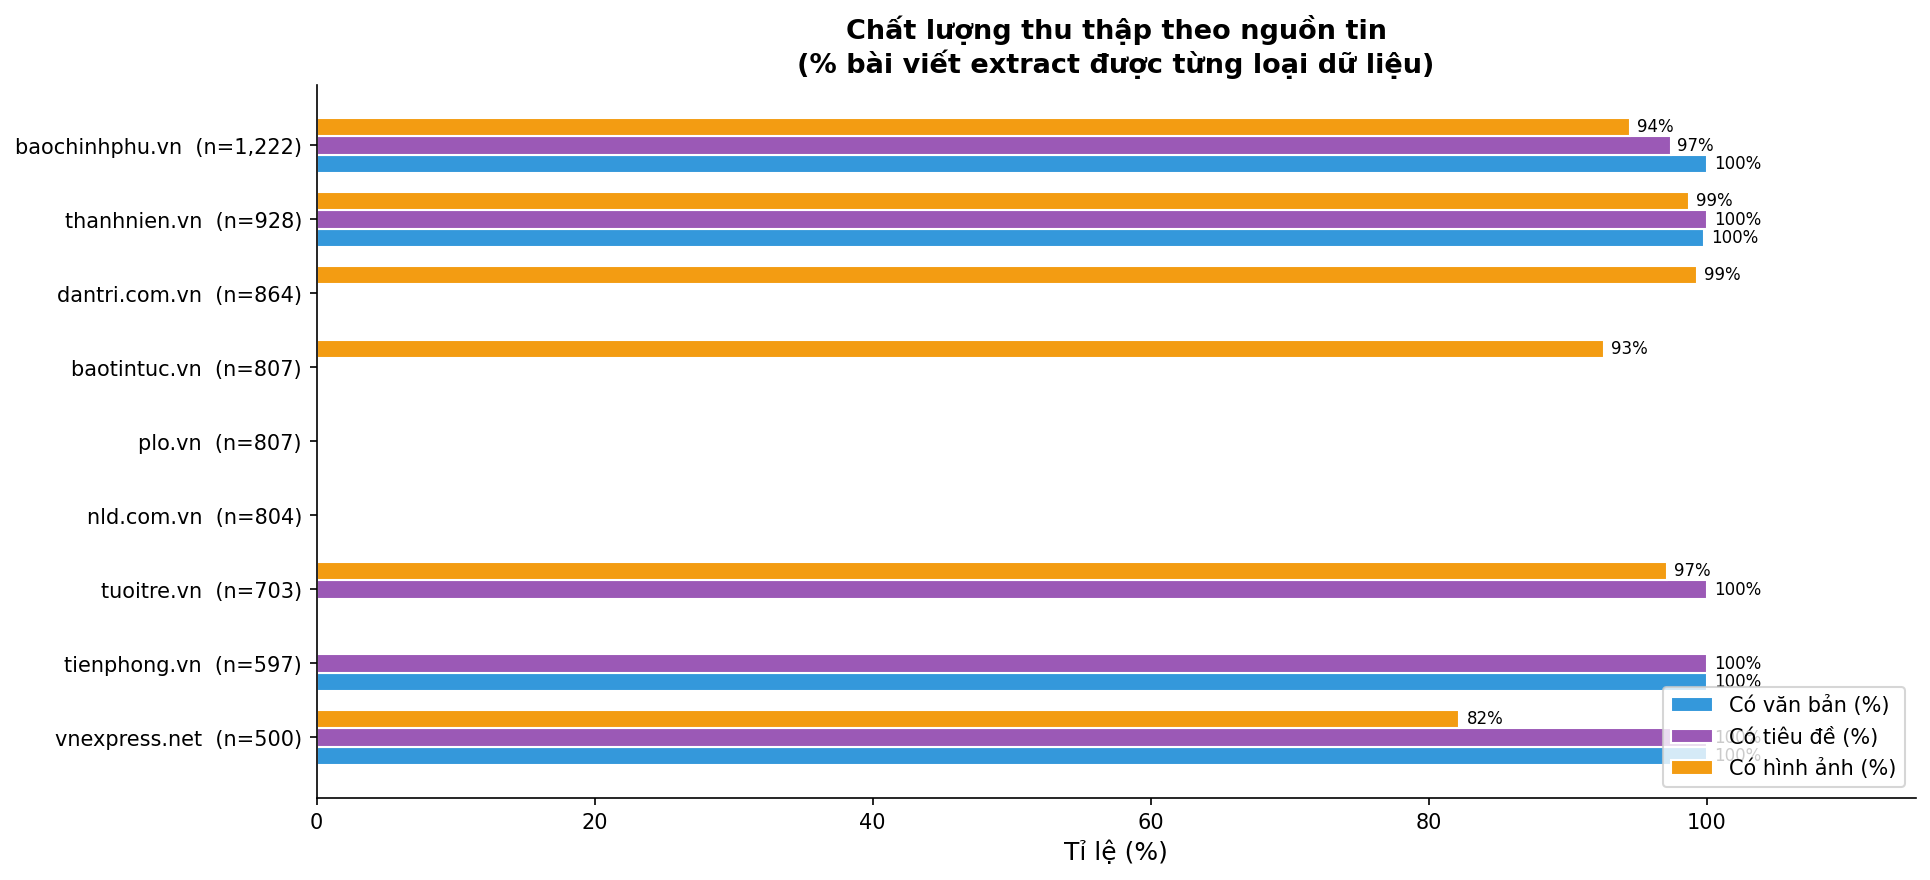

Saved: fig9_crawl_quality_by_domain.png

Bảng chất lượng crawl theo domain:


,Tổng,Có text (%),Có title (%),Có ảnh (%),Avg text len,Avg ảnh,Avg links
Nguồn tin,,,,,,,
baochinhphu.vn,1222,100.000000,97.400000,94.400000,3635.500000,1.900000,0.000000
thanhnien.vn,928,99.800000,100.000000,98.700000,2528.600000,2.400000,3.000000
dantri.com.vn,864,0.000000,0.000000,99.300000,0.000000,2.600000,0.000000
baotintuc.vn,807,0.000000,0.000000,92.600000,0.000000,1.600000,0.000000
plo.vn,807,0.000000,0.000000,0.000000,0.000000,0.000000,79.800000
nld.com.vn,804,0.000000,0.000000,0.000000,0.000000,0.000000,0.700000
tuoitre.vn,703,0.000000,100.000000,97.200000,0.000000,1.800000,1.700000
tienphong.vn,597,100.000000,100.000000,0.000000,2555.100000,0.000000,1.000000
vnexpress.net,500,100.000000,100.000000,82.200000,2782.300000,1.300000,0.800000


In [15]:
# Build per-domain crawl quality stats from crawled data
df["has_title"] = df["title"].str.strip().str.len() > 0
df["title_length"] = df["title"].str.len()

domain_quality = (
    df.groupby("domain")
    .agg(
        total       =("id", "count"),
        pct_text    =("has_text",   "mean"),
        pct_title   =("has_title",  "mean"),
        pct_images  =("has_images", "mean"),
        avg_text_len=("text_length","mean"),
        avg_img_cnt =("image_count","mean"),
        avg_links   =("link_count", "mean"),
    )
    .reset_index()
)
domain_quality[["pct_text","pct_title","pct_images"]] *= 100

# Sort by total descending
domain_quality = domain_quality.sort_values("total", ascending=False).reset_index(drop=True)

# ── Grouped horizontal bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

domains = domain_quality["domain"].tolist()
y = np.arange(len(domains))
h = 0.25

bars_text  = ax.barh(y + h,   domain_quality["pct_text"],   h, label="Có văn bản (%)",  color="#3498db", edgecolor="white")
bars_title = ax.barh(y,       domain_quality["pct_title"],  h, label="Có tiêu đề (%)",  color="#9b59b6", edgecolor="white")
bars_img   = ax.barh(y - h,   domain_quality["pct_images"], h, label="Có hình ảnh (%)", color="#f39c12", edgecolor="white")

for bar_set in [bars_text, bars_title, bars_img]:
    for bar in bar_set:
        w = bar.get_width()
        if w > 2:
            ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
                    f"{w:.0f}%", va="center", ha="left", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels([f"{d}  (n={int(domain_quality.loc[domain_quality.domain==d,'total'].values[0]):,})"
                    for d in domains], fontsize=10)
ax.set_xlim(0, 115)
ax.set_xlabel("Tỉ lệ (%)")
ax.set_title("Chất lượng thu thập theo nguồn tin\n(% bài viết extract được từng loại dữ liệu)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("fig9_crawl_quality_by_domain.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig9_crawl_quality_by_domain.png")

# Print table
print("\nBảng chất lượng crawl theo domain:")
display(domain_quality.rename(columns={
    "domain":"Nguồn tin","total":"Tổng","pct_text":"Có text (%)","pct_title":"Có title (%)",
    "pct_images":"Có ảnh (%)","avg_text_len":"Avg text len","avg_img_cnt":"Avg ảnh","avg_links":"Avg links"
}).round(1).set_index("Nguồn tin").style.background_gradient(
    subset=["Có text (%)","Có title (%)","Có ảnh (%)"], cmap="RdYlGn", vmin=0, vmax=100
))

## 13. Độ dài văn bản theo nguồn tin

Phân tích độ dài văn bản thực tế crawled — chỉ tính các bài viết **có nội dung** (`text_length > 0`).

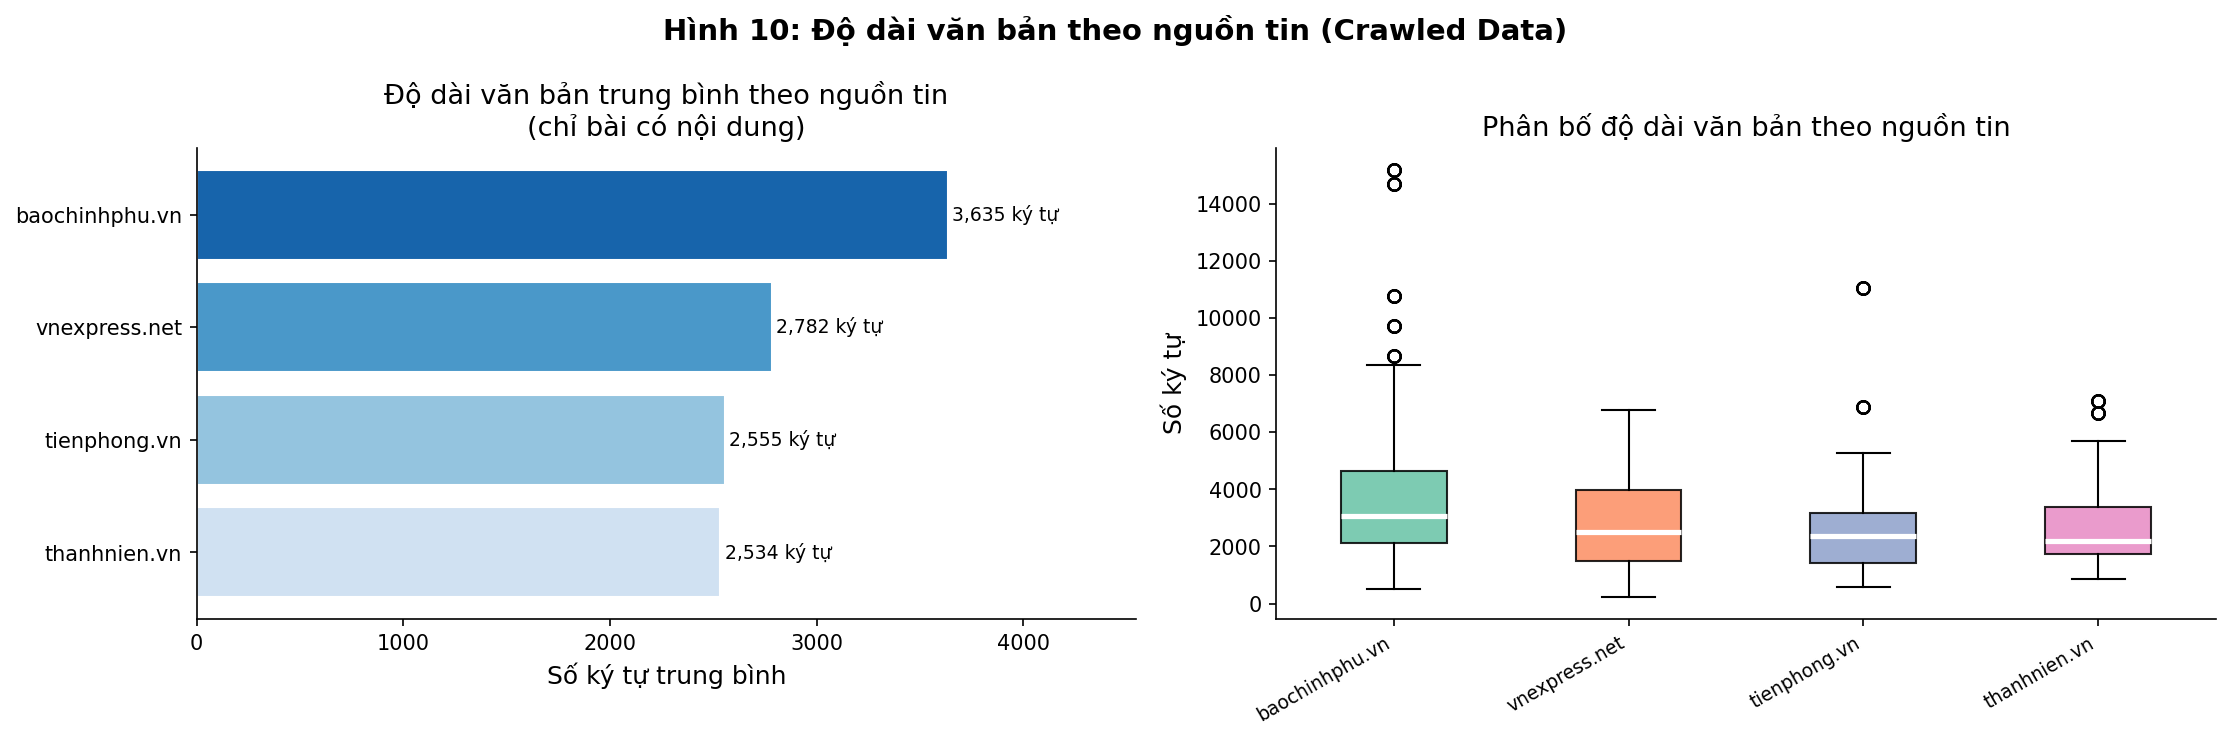

Saved: fig10_text_length_by_domain.png

Chi tiết thống kê văn bản theo nguồn tin:


,count,mean,std,min,25%,50%,75%,max
domain,,,,,,,,
baochinhphu.vn,1222,3635,2254,505,2118,3062,4637,15197
thanhnien.vn,926,2534,1138,845,1728,2187,3366,7084
tienphong.vn,597,2555,1504,593,1425,2364,3162,11038
vnexpress.net,500,2782,1582,215,1475,2514,3965,6775


In [16]:
df_text = df[df["has_text"]].copy()

# Domains that have text
text_domains = df_text["domain"].value_counts()
text_domains = text_domains[text_domains > 0].index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: average text length per domain (horizontal bar)
avg_by_domain = (
    df_text.groupby("domain")["text_length"]
    .mean()
    .sort_values(ascending=True)
)
colors_bar = sns.color_palette("Blues", len(avg_by_domain))
axes[0].barh(avg_by_domain.index, avg_by_domain.values,
             color=colors_bar, edgecolor="white")
for i, (dom, val) in enumerate(zip(avg_by_domain.index, avg_by_domain.values)):
    axes[0].text(val + 20, i, f"{val:,.0f} ký tự", va="center", fontsize=9)
axes[0].set_title("Độ dài văn bản trung bình theo nguồn tin\n(chỉ bài có nội dung)")
axes[0].set_xlabel("Số ký tự trung bình")
axes[0].set_xlim(0, avg_by_domain.max() * 1.25)

# Right: boxplot — distribution of text_length per domain
domain_order = df_text.groupby("domain")["text_length"].median().sort_values(ascending=False).index.tolist()
data_by_dom = [df_text[df_text["domain"] == d]["text_length"].values for d in domain_order]
bp = axes[1].boxplot(data_by_dom, patch_artist=True, vert=True,
                     medianprops=dict(color="white", linewidth=2.5))
palette = sns.color_palette("Set2", len(domain_order))
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[1].set_xticks(range(1, len(domain_order)+1))
axes[1].set_xticklabels(domain_order, rotation=30, ha="right", fontsize=9)
axes[1].set_title("Phân bố độ dài văn bản theo nguồn tin")
axes[1].set_ylabel("Số ký tự")

plt.suptitle("Hình 10: Độ dài văn bản theo nguồn tin (Crawled Data)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig10_text_length_by_domain.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig10_text_length_by_domain.png")
print()
print("Chi tiết thống kê văn bản theo nguồn tin:")
domain_text_stats = df_text.groupby("domain")["text_length"].describe().round(0).astype(int)
display(domain_text_stats)

## 14. Số lượng liên kết (Link Count — Crawled Data)

`link_count` là số liên kết ngoài trích xuất từ nội dung bài viết.

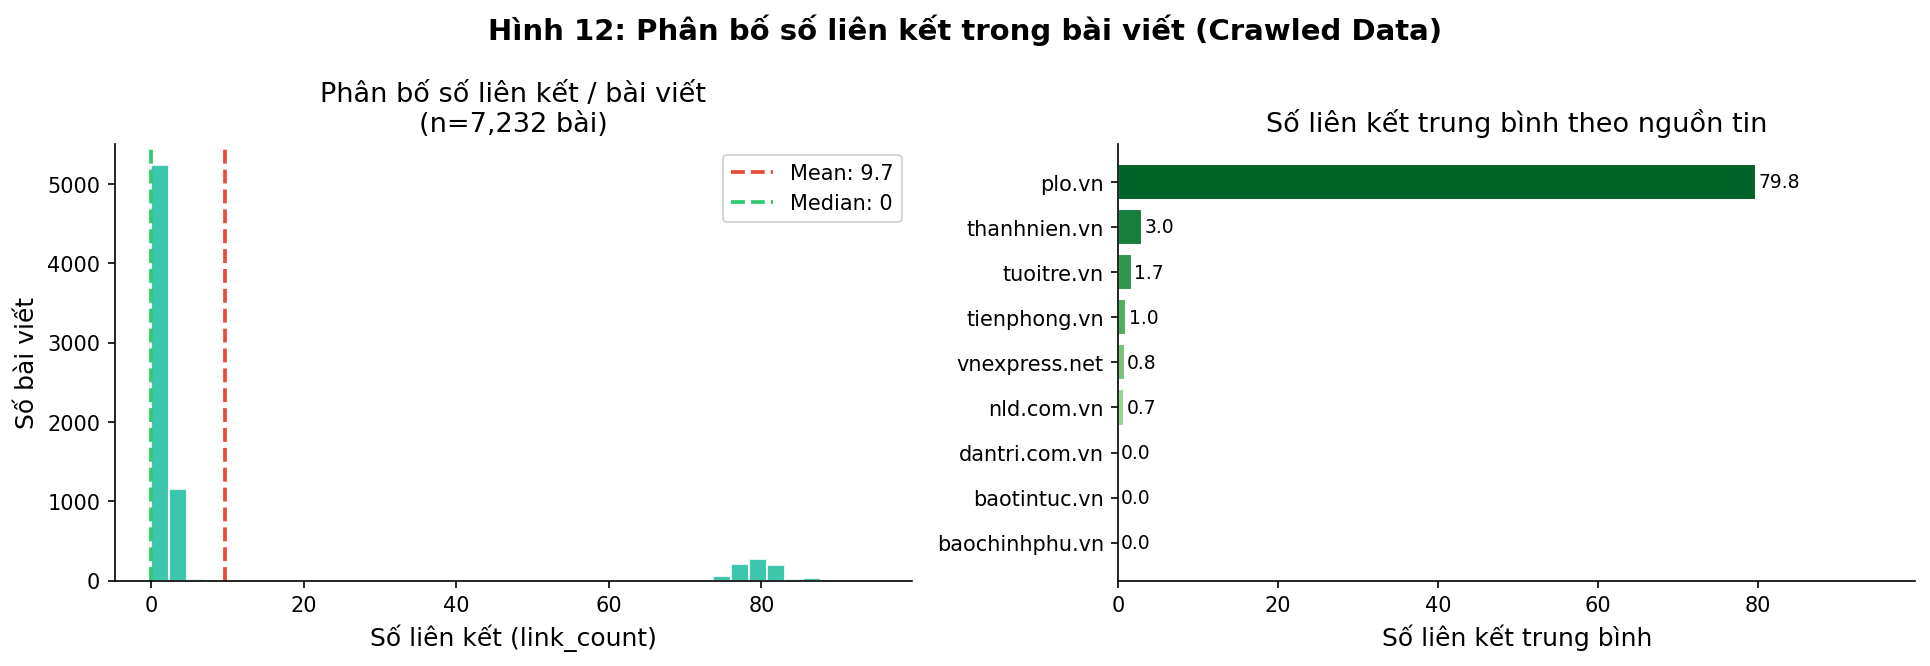

Saved: fig12_link_count.png

Tổng bài có liên kết (link_count > 0): 3,460 (47.8%)
link_count max: 95
link_count mean (tất cả): 9.66
link_count mean (bài có link): 20.20


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 16a: Link count histogram (log-scale for skewed distribution)
link_vals = df["link_count"]
nonzero   = link_vals[link_vals > 0]
axes[0].hist(link_vals, bins=40, color="#1abc9c", edgecolor="white", alpha=0.85)
axes[0].axvline(link_vals.mean(),   color="#e74c3c", ls="--", lw=1.8, label=f"Mean: {link_vals.mean():.1f}")
axes[0].axvline(link_vals.median(), color="#2ecc71", ls="--", lw=1.8, label=f"Median: {link_vals.median():.0f}")
axes[0].set_title(f"Phân bố số liên kết / bài viết\n(n={len(df):,} bài)")
axes[0].set_xlabel("Số liên kết (link_count)")
axes[0].set_ylabel("Số bài viết")
axes[0].legend()

# 16b: Average link count per domain (horizontal bar)
avg_links_dom = (
    df.groupby("domain")["link_count"]
    .mean()
    .sort_values(ascending=True)
)
colors_l = sns.color_palette("Greens", len(avg_links_dom))
axes[1].barh(avg_links_dom.index, avg_links_dom.values, color=colors_l, edgecolor="white")
for i, (dom, val) in enumerate(zip(avg_links_dom.index, avg_links_dom.values)):
    axes[1].text(val + 0.3, i, f"{val:.1f}", va="center", fontsize=9)
axes[1].set_title("Số liên kết trung bình theo nguồn tin")
axes[1].set_xlabel("Số liên kết trung bình")
axes[1].set_xlim(0, avg_links_dom.max() * 1.25)

plt.suptitle("Hình 12: Phân bố số liên kết trong bài viết (Crawled Data)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig12_link_count.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig12_link_count.png")
print()
print(f"Tổng bài có liên kết (link_count > 0): {(df['link_count'] > 0).sum():,} ({(df['link_count']>0).mean()*100:.1f}%)")
print(f"link_count max: {df['link_count'].max()}")
print(f"link_count mean (tất cả): {df['link_count'].mean():.2f}")
print(f"link_count mean (bài có link): {df[df['link_count']>0]['link_count'].mean():.2f}")

---
## Tóm tắt

### Thống kê từ ViFactCheck (metadata)
| Hạng mục | Giá trị |
|---|---|
| Tổng số mẫu | 7,232 |
| Train / Dev / Test | 5,062 / 723 / 1,447 |
| Nhãn 0 — Supported | 2,568 (35.5%) |
| Nhãn 1 — Refuted | 2,432 (33.6%) |
| Nhãn 2 — Not Enough Info | 2,232 (30.9%) |
| Số chủ đề (topic) | 20+ |

### Thống kê từ dữ liệu crawled
| Hạng mục | Giá trị |
|---|---|
| Nguồn tin (domain) | 9 báo điện tử lớn |
| Có văn bản (text) | ~3,245 bài (44.9%) |
| Có hình ảnh | ~4,769 bài (65.9%) |
| Độ dài TB văn bản | ~2,991 ký tự |
| Đoạn văn TB | ~11.5 đoạn |
| Nguồn có text 100% | baochinhphu, thanhnien, tienphong, vnexpress |
| Nguồn không có text | dantri, plo, baotintuc, nld, tuoitre |

> **5/9 nguồn tin không extract được văn bản** — model cần tận dụng kết hợp tiêu đề, hình ảnh và tuyên bố (Statement) từ ViFactCheck.